# Mask2Former ScanNet Instance Segmentation with NYU40

This notebook fine-tunes `facebook/mask2former-swin-base-ade-semantic` from Hugging Face Transformers on ScanNet frame data in `Datasets/ScanNet/scannet_frames_25k`.

It builds instance targets from the ScanNet `instance/` and `label/` PNGs, remaps ScanNet NYU ids to NYU40 using `SceneGraph/scannet-labels.combined.tsv`, and optionally seeds the NYU classifier head from `SceneGraph/ade2nyu.csv`.

In [82]:
from __future__ import annotations

import csv
import json
import random
import subprocess
import sys
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Any


def ensure_package(import_name: str, pip_name: str | None = None) -> None:
    try:
        __import__(import_name)
    except Exception:
        package_name = pip_name or import_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])


def ensure_pinned_package(import_name: str, pinned_spec: str) -> None:
    _ = import_name
    # Always enforce pinned versions to avoid runtime incompatibilities.
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pinned_spec])


ensure_package("torch")
ensure_package("numpy")
ensure_package("PIL", "Pillow")
ensure_pinned_package("transformers", "transformers==4.41.2")
ensure_pinned_package("accelerate", "accelerate==0.31.0")
ensure_package("pandas")
ensure_package("tqdm")

import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset

# Compatibility shim for environments where DTensor lives under torch.distributed._tensor.
try:
    from torch.distributed.tensor import DTensor as _DTensor  # noqa: F401
except Exception:
    try:
        from torch.distributed._tensor import DTensor as _DTensor  # type: ignore
        import torch.distributed.tensor as _dist_tensor

        _dist_tensor.DTensor = _DTensor
    except Exception:
        pass

from transformers import (
    AutoImageProcessor,
    Mask2FormerForUniversalSegmentation,
    Trainer,
    TrainingArguments,
)

ROOT = Path("/home/abdou/Projects/Python/RTSGS").resolve()
SCENEGRAPH_ROOT = ROOT / "SceneGraph"
NYU_ROOT = SCENEGRAPH_ROOT / "nyu_semseg_full"
NYU_IMAGES_ROOT = NYU_ROOT / "images"
NYU_LABELS_ROOT = NYU_ROOT / "labels"
SCANNET_LABELS_TSV = SCENEGRAPH_ROOT / "scannet-labels.combined.tsv"
ADE2NYU_CSV = SCENEGRAPH_ROOT / "ade2nyu.csv"

assert NYU_ROOT.exists(), f"NYU dataset root not found: {NYU_ROOT}"
assert NYU_IMAGES_ROOT.exists(), f"NYU image root not found: {NYU_IMAGES_ROOT}"
assert NYU_LABELS_ROOT.exists(), f"NYU label root not found: {NYU_LABELS_ROOT}"
assert SCANNET_LABELS_TSV.exists(), f"Mapping file not found: {SCANNET_LABELS_TSV}"
assert ADE2NYU_CSV.exists(), f"ADE->NYU mapping file not found: {ADE2NYU_CSV}"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Workspace root:", ROOT)
print("NYU root:", NYU_ROOT)
print("Device:", device)
print("Torch:", torch.__version__)
print("Transformers:", __import__("transformers").__version__)
print("Accelerate:", __import__("accelerate").__version__)

Workspace root: /home/abdou/Projects/Python/RTSGS
NYU root: /home/abdou/Projects/Python/RTSGS/SceneGraph/nyu_semseg_full
Device: cuda
Torch: 2.1.2
Transformers: 4.52.4
Accelerate: 1.13.0


Loaded ADE->NYU40 pairs (for classifier transfer only): 150
Loaded ADE classes: 150
Loaded NYU40 classes from ScanNet TSV: 40
Example NYU40 classes: ['wall', 'floor', 'cabinet', 'bed', 'chair', 'sofa', 'table', 'door', 'window', 'bookshelf']
Train split samples: 1305
Val split samples: 144
Split: train Image: nyu_000000
Image size: (640, 480)
Pseudo instance ids: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Raw semantic ids: [0, 1, 4, 6, 8, 10, 19, 22, 255]
Instances with class labels: 8
Sample mapping: [(1, 0), (2, 1), (3, 4), (4, 6), (5, 8), (6, 10), (7, 19), (8, 22)]


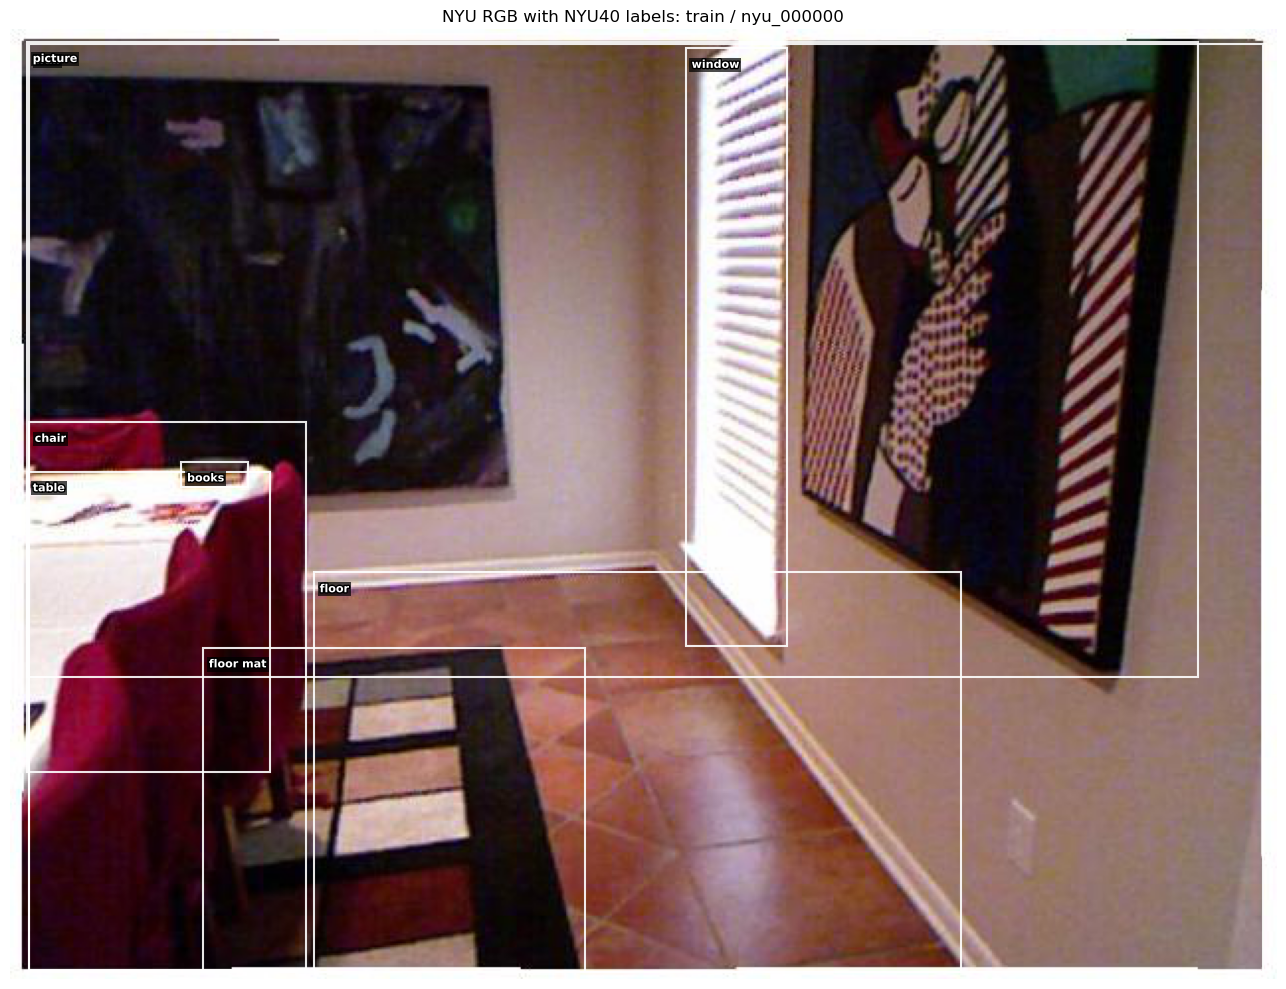

In [86]:
def load_ade_to_nyu40_mapping(csv_path: Path) -> tuple[dict[int, int], dict[int, str], list[str]]:
    frame = pd.read_csv(csv_path)
    ade_to_nyu40: dict[int, int] = {}
    ade_index_to_class: dict[int, str] = {}
    nyu40_names = ["unknown"] * 40

    for _, row in frame.iterrows():
        ade_index = int(row["ade_index"])
        ade_class = str(row["ade_class"]).strip()
        nyu40_index = int(row["nyu40_index"])
        nyu40_class = str(row["nyu40_class"]).strip()

        ade_index_to_class[ade_index] = ade_class
        if 0 <= nyu40_index < 40:
            ade_to_nyu40[ade_index] = nyu40_index
            if nyu40_class:
                nyu40_names[nyu40_index] = nyu40_class

    return ade_to_nyu40, ade_index_to_class, nyu40_names


def load_nyu40_names_from_scannet_tsv(tsv_path: Path) -> list[str]:
    names = [f"nyu40_{i:02d}" for i in range(40)]
    with open(tsv_path, "r", newline="", encoding="utf-8", errors="replace") as handle:
        reader = csv.DictReader(handle, delimiter="\t")
        for row in reader:
            nyu40_id = (row.get("nyu40id") or "").strip()
            nyu40_class = (row.get("nyu40class") or "").strip()
            if not nyu40_id.isdigit():
                continue
            nyu40_id_int = int(nyu40_id)
            if 1 <= nyu40_id_int <= 40 and nyu40_class:
                names[nyu40_id_int - 1] = nyu40_class
    return names


if "SCENEGRAPH_ROOT" not in globals():
    SCENEGRAPH_ROOT = ROOT / "SceneGraph"
if "ADE2NYU_CSV" not in globals():
    ADE2NYU_CSV = SCENEGRAPH_ROOT / "ade2nyu.csv"
if "SCANNET_LABELS_TSV" not in globals():
    SCANNET_LABELS_TSV = SCENEGRAPH_ROOT / "scannet-labels.combined.tsv"
if "NYU_ROOT" not in globals():
    NYU_ROOT = SCENEGRAPH_ROOT / "nyu_semseg_full"
if "NYU_IMAGES_ROOT" not in globals():
    NYU_IMAGES_ROOT = NYU_ROOT / "images"
if "NYU_LABELS_ROOT" not in globals():
    NYU_LABELS_ROOT = NYU_ROOT / "labels"

ADE_TO_NYU40, ADE_INDEX_TO_CLASS, NYU40_CLASS_NAMES_FROM_ADE = load_ade_to_nyu40_mapping(ADE2NYU_CSV)
NYU40_CLASS_NAMES = load_nyu40_names_from_scannet_tsv(SCANNET_LABELS_TSV)
RAW_IGNORE_IDS = {255}
IGNORE_INDEX = 255

print("Loaded ADE->NYU40 pairs (for classifier transfer only):", len(ADE_TO_NYU40))
print("Loaded ADE classes:", len(ADE_INDEX_TO_CLASS))
print("Loaded NYU40 classes from ScanNet TSV:", len(NYU40_CLASS_NAMES))
print("Example NYU40 classes:", NYU40_CLASS_NAMES[:10])


def normalize_semantic_id(raw_id: int) -> int:
    raw_id = int(raw_id)
    if raw_id in RAW_IGNORE_IDS:
        return IGNORE_INDEX

    # nyu_semseg_full labels are already in NYU40 contiguous space [0..39].
    if 0 <= raw_id < 40:
        return raw_id

    # Robust fallback for 1-based NYU40 labels [1..40].
    if 1 <= raw_id <= 40:
        return raw_id - 1

    return IGNORE_INDEX


def read_mask(path: Path) -> np.ndarray:
    array = np.array(Image.open(path))
    if array.ndim == 3:
        array = array[..., 0]
    return array.astype(np.int32)


def semantic_to_pseudo_instance_map(semantic_map: np.ndarray) -> np.ndarray:
    # Create one pseudo-instance per mapped NYU40 class in this frame.
    instance_map = np.zeros_like(semantic_map, dtype=np.int32)
    normalized_map = np.full_like(semantic_map, IGNORE_INDEX, dtype=np.int32)

    unique_raw_ids = [int(x) for x in np.unique(semantic_map).tolist()]
    for raw_id in unique_raw_ids:
        cls = normalize_semantic_id(raw_id)
        if cls == IGNORE_INDEX:
            continue
        normalized_map[semantic_map == raw_id] = cls

    next_instance_id = 1
    for cls in sorted(int(x) for x in np.unique(normalized_map).tolist()):
        if cls == IGNORE_INDEX:
            continue
        mask = normalized_map == cls
        if not np.any(mask):
            continue
        instance_map[mask] = next_instance_id
        next_instance_id += 1

    return instance_map


def build_instance_to_semantic_map(instance_map: np.ndarray, semantic_map: np.ndarray) -> dict[int, int]:
    mapping: dict[int, int] = {}
    for instance_id in np.unique(instance_map):
        instance_id = int(instance_id)
        if instance_id == 0:
            continue
        mask = instance_map == instance_id
        if not np.any(mask):
            continue
        labels = semantic_map[mask].astype(np.int32)
        labels = np.array([normalize_semantic_id(int(label)) for label in labels], dtype=np.int32)
        labels = labels[labels != IGNORE_INDEX]
        if labels.size == 0:
            continue
        majority_label = int(Counter(labels.tolist()).most_common(1)[0][0])
        mapping[instance_id] = majority_label
    return mapping


@dataclass
class SampleRecord:
    split: str
    image_id: str
    image_path: Path
    semantic_path: Path


class NYUSemanticAsInstanceDataset(Dataset):
    def __init__(self, image_root: Path, label_root: Path, split: str, max_samples: int | None = None):
        self.samples: list[SampleRecord] = []
        split_image_dir = image_root / split
        split_label_dir = label_root / split
        assert split_image_dir.exists(), f"Missing NYU image split dir: {split_image_dir}"
        assert split_label_dir.exists(), f"Missing NYU label split dir: {split_label_dir}"

        image_paths = [path for path in sorted(split_image_dir.glob("*")) if path.suffix.lower() in {".jpg", ".jpeg", ".png"}]
        for image_path in image_paths:
            image_id = image_path.stem
            semantic_path = split_label_dir / f"{image_id}.png"
            if semantic_path.exists():
                self.samples.append(
                    SampleRecord(
                        split=split,
                        image_id=image_id,
                        image_path=image_path,
                        semantic_path=semantic_path,
                    )
                )

        if max_samples is not None:
            self.samples = self.samples[:max_samples]

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int) -> dict[str, Any]:
        record = self.samples[index]
        image = Image.open(record.image_path).convert("RGB")
        semantic_map = read_mask(record.semantic_path)
        instance_map = semantic_to_pseudo_instance_map(semantic_map)
        return {
            "image": image,
            "instance_map": instance_map,
            "semantic_map": semantic_map,
            "scene_id": record.split,
            "frame_id": record.image_id,
        }


MAX_TRAIN_SAMPLES = None
MAX_VAL_SAMPLES = None

train_dataset = NYUSemanticAsInstanceDataset(NYU_IMAGES_ROOT, NYU_LABELS_ROOT, split="train", max_samples=MAX_TRAIN_SAMPLES)
val_dataset = NYUSemanticAsInstanceDataset(NYU_IMAGES_ROOT, NYU_LABELS_ROOT, split="val", max_samples=MAX_VAL_SAMPLES)

print("Train split samples:", len(train_dataset))
print("Val split samples:", len(val_dataset))


def inspect_dataset_sample(dataset: Dataset, index: int = 0) -> None:
    sample = dataset[index]
    image = sample["image"]
    instance_map = sample["instance_map"]
    semantic_map = sample["semantic_map"]
    instance_to_semantic = build_instance_to_semantic_map(instance_map, semantic_map)
    annotated_image = np.array(image).copy()
    print("Split:", sample["scene_id"], "Image:", sample["frame_id"])
    print("Image size:", image.size)
    print("Pseudo instance ids:", sorted(int(x) for x in np.unique(instance_map).tolist())[:20])
    print("Raw semantic ids:", sorted(int(x) for x in np.unique(semantic_map).tolist())[:20])
    print("Instances with class labels:", len(instance_to_semantic))
    print("Sample mapping:", list(instance_to_semantic.items())[:10])

    import matplotlib.patches as patches
    import matplotlib.pyplot as plt
    import matplotlib.patheffects as path_effects

    _, ax = plt.subplots(1, 1, figsize=(14, 10))
    ax.imshow(annotated_image)
    ax.set_title(f"NYU RGB with NYU40 labels: {sample['scene_id']} / {sample['frame_id']}")
    ax.axis("off")

    for instance_id, class_index in sorted(instance_to_semantic.items()):
        mask = instance_map == instance_id
        if not np.any(mask):
            continue
        ys, xs = np.where(mask)
        y0, y1 = int(ys.min()), int(ys.max())
        x0, x1 = int(xs.min()), int(xs.max())

        mapped_class_name = NYU40_CLASS_NAMES[class_index] if 0 <= class_index < len(NYU40_CLASS_NAMES) else "unknown"

        ax.add_patch(
            patches.Rectangle(
                (x0, y0),
                max(1, x1 - x0 + 1),
                max(1, y1 - y0 + 1),
                linewidth=1.5,
                edgecolor="white",
                facecolor="none",
                alpha=0.9,
            )
        )
        text_x = x0 + 3
        text_y = max(10, y0 + 10)
        text = ax.text(
            text_x,
            text_y,
            mapped_class_name,
            fontsize=8,
            color="white",
            weight="bold",
            bbox={"facecolor": "black", "alpha": 0.7, "pad": 1.5, "edgecolor": "none"},
        )
        text.set_path_effects([path_effects.withStroke(linewidth=2, foreground="black")])

    plt.tight_layout()
    plt.show()


inspect_dataset_sample(train_dataset, 0)

Image: nyu_000000.jpg
Raw semantic ids: [0, 1, 4, 6, 8, 10, 19, 22, 255]
Pseudo instances: 8


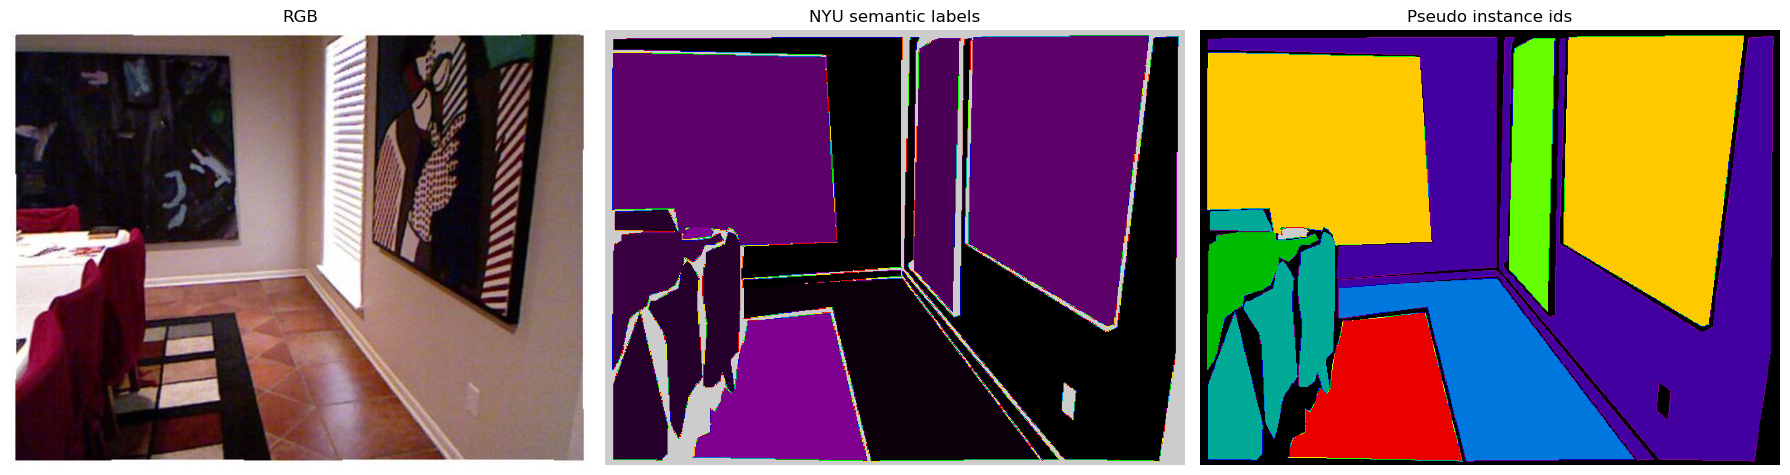

In [88]:
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

ROOT = Path("/home/abdou/Projects/Python/RTSGS").resolve()
NYU_ROOT = ROOT / "SceneGraph" / "nyu_semseg_full"
image_dir = NYU_ROOT / "images" / "train"
semantic_dir = NYU_ROOT / "labels" / "train"

image_candidates = [
    path for path in sorted(image_dir.glob("*"))
    if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
]
if not image_candidates:
    raise FileNotFoundError(f"No NYU images found under {image_dir}")

image_path = image_candidates[0]
frame_id = image_path.stem
semantic_path = semantic_dir / f"{frame_id}.png"

if not semantic_path.exists():
    raise FileNotFoundError(f"Semantic label file not found: {semantic_path}")

image = Image.open(image_path).convert("RGB")
semantic_map = np.array(Image.open(semantic_path))
if semantic_map.ndim == 3:
    semantic_map = semantic_map[..., 0]
semantic_map = semantic_map.astype(np.int32)

# For NYU semseg, we create one pseudo-instance per class for visualization/training compatibility.
instance_map = np.zeros_like(semantic_map, dtype=np.int32)
next_instance_id = 1
for cls in sorted(int(x) for x in np.unique(semantic_map).tolist()):
    if cls in {255}:
        continue
    mask = semantic_map == cls
    if not np.any(mask):
        continue
    instance_map[mask] = next_instance_id
    next_instance_id += 1

raw_ids = sorted(int(x) for x in np.unique(semantic_map).tolist())
print("Image:", image_path.name)
print("Raw semantic ids:", raw_ids[:40])
print("Pseudo instances:", next_instance_id - 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(image)
axes[0].set_title("RGB")
axes[0].axis("off")

axes[1].imshow(semantic_map, cmap="nipy_spectral")
axes[1].set_title("NYU semantic labels")
axes[1].axis("off")

axes[2].imshow(instance_map, cmap="nipy_spectral")
axes[2].set_title("Pseudo instance ids")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Model and Class Transfer

This section loads the Hugging Face checkpoint, switches it to 40 NYU classes, and optionally seeds the classifier head with ADE weights matched through `ade2nyu.csv`.

In [100]:
BASE_MODEL_ID = "facebook/mask2former-swin-base-ade-semantic"
NUM_CLASSES = 40
OUTPUT_DIR = ROOT / "outputs" / "mask2former_scannet_nyu40_instance"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def canonicalize_label_name(name: str) -> str:
    return "".join(ch.lower() for ch in str(name) if ch.isalnum())


id2label = {idx: name for idx, name in enumerate(NYU40_CLASS_NAMES)}
label2id = {name: idx for idx, name in id2label.items()}

processor = AutoImageProcessor.from_pretrained(BASE_MODEL_ID)
if hasattr(processor, "size"):
    processor.size = {"shortest_edge": 512, "longest_edge": 768}
if hasattr(processor, "do_reduce_labels"):
    processor.do_reduce_labels = False
if hasattr(processor, "size_divisor"):
    processor.size_divisor = 32

base_model = Mask2FormerForUniversalSegmentation.from_pretrained(BASE_MODEL_ID)
model = Mask2FormerForUniversalSegmentation.from_pretrained(
    BASE_MODEL_ID,
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

if hasattr(model.config, "id2label"):
    model.config.id2label = id2label
if hasattr(model.config, "label2id"):
    model.config.label2id = label2id
if hasattr(model.config, "num_labels"):
    model.config.num_labels = NUM_CLASSES
if hasattr(model.config, "ignore_value"):
    model.config.ignore_value = IGNORE_INDEX


def transfer_class_predictor_weights(source_model, target_model, mapping_csv: Path) -> dict[str, int]:
    source_state = source_model.class_predictor.state_dict()
    target_weight = target_model.class_predictor.weight.data
    target_bias = target_model.class_predictor.bias.data
    source_names = {canonicalize_label_name(name): int(idx) for idx, name in source_model.config.id2label.items()}
    mapping = pd.read_csv(mapping_csv)
    transferred = 0

    for nyu40_index in range(NUM_CLASSES):
        rows = mapping[mapping["nyu40_index"] == nyu40_index]
        source_ids = []
        for _, row in rows.iterrows():
            ade_name = canonicalize_label_name(row["ade_class"])
            if ade_name in source_names:
                source_ids.append(source_names[ade_name])
        if not source_ids:
            continue
        target_weight[nyu40_index].copy_(source_state["weight"][source_ids].mean(dim=0))
        target_bias[nyu40_index].copy_(source_state["bias"][source_ids].mean(dim=0))
        transferred += 1

    target_weight[-1].copy_(source_state["weight"][-1])
    target_bias[-1].copy_(source_state["bias"][-1])
    return {"classes_transferred": transferred}


transfer_info = transfer_class_predictor_weights(base_model, model, ADE2NYU_CSV)
model.to(device)

print("Base checkpoint:", BASE_MODEL_ID)
print("Output dir:", OUTPUT_DIR)
print("Model classes:", len(NYU40_CLASS_NAMES))
print("Transferred classes:", transfer_info["classes_transferred"])
print("Model class predictor shape:", tuple(model.class_predictor.weight.shape))


def build_instance_targets(instance_map: np.ndarray, semantic_map: np.ndarray) -> tuple[torch.Tensor, torch.Tensor]:
    instance_ids = [int(x) for x in np.unique(instance_map).tolist() if int(x) != 0]
    mask_list: list[torch.Tensor] = []
    class_list: list[torch.Tensor] = []

    for instance_id in instance_ids:
        mask = instance_map == instance_id
        if not np.any(mask):
            continue
        labels = semantic_map[mask].astype(np.int32)
        labels = np.array([normalize_semantic_id(int(label)) for label in labels], dtype=np.int32)
        labels = labels[labels != IGNORE_INDEX]
        if labels.size == 0:
            continue
        majority_label = int(Counter(labels.tolist()).most_common(1)[0][0])
        mask_list.append(torch.from_numpy(mask.astype(np.float32)))
        class_list.append(torch.tensor(majority_label, dtype=torch.long))

    if mask_list:
        mask_tensor = torch.stack(mask_list, dim=0)
        class_tensor = torch.stack(class_list, dim=0)
    else:
        height, width = instance_map.shape
        mask_tensor = torch.zeros((0, height, width), dtype=torch.float32)
        class_tensor = torch.zeros((0,), dtype=torch.long)
    return mask_tensor, class_tensor


def collate_fn(batch: list[dict[str, Any]]) -> dict[str, Any]:
    images = [item["image"] for item in batch]
    encoded = processor(images=images, return_tensors="pt")
    encoded["mask_labels"] = []
    encoded["class_labels"] = []
    for item in batch:
        masks, labels = build_instance_targets(item["instance_map"], item["semantic_map"])
        encoded["mask_labels"].append(masks)
        encoded["class_labels"].append(labels)
    return encoded


preview_batch = collate_fn([train_dataset[0], train_dataset[min(1, len(train_dataset) - 1)]])
print("Batch keys:", list(preview_batch.keys()))
print("pixel_values:", tuple(preview_batch["pixel_values"].shape))
print("pixel_mask:", tuple(preview_batch["pixel_mask"].shape))
print("mask label counts:", [len(x) for x in preview_batch["mask_labels"]])
print("class label counts:", [len(x) for x in preview_batch["class_labels"]])

with torch.no_grad():
    preview_outputs = model(
        pixel_values=preview_batch["pixel_values"].to(device),
        pixel_mask=preview_batch["pixel_mask"].to(device),
        mask_labels=[x.to(device) for x in preview_batch["mask_labels"]],
        class_labels=[x.to(device) for x in preview_batch["class_labels"]],
    )

print("Preview loss:", float(preview_outputs.loss.detach().cpu()))
print("class_queries_logits:", tuple(preview_outputs.class_queries_logits.shape))
print("masks_queries_logits:", tuple(preview_outputs.masks_queries_logits.shape))


'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /facebook/mask2former-swin-base-ade-semantic/resolve/main/preprocessor_config.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x781c71751710>: Failed to resolve \'huggingface.co\' ([Errno -3] Temporary failure in name resolution)"))'), '(Request ID: 6deaedd8-3e54-413e-850e-0bb90765f638)')' thrown while requesting HEAD https://huggingface.co/facebook/mask2former-swin-base-ade-semantic/resolve/main/preprocessor_config.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /facebook/mask2former-swin-base-ade-semantic/resolve/main/preprocessor_config.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x781c71850710>: Failed to resolve \'huggingface.co\' ([Errno -3] Temporary failure in name resolution)"))'), '(Request ID: 5d8374e7-a2dc-47c5-

KeyboardInterrupt: 

In [90]:
# Freeze everything first.
for _, parameter in model.named_parameters():
    parameter.requires_grad = False

# Unfreeze the full classification branch:
# - transformer query/decoder branch (produces class-query features)
# - final class predictor head
for name, parameter in model.named_parameters():
    if name.startswith("model.transformer_module") or name.startswith("class_predictor"):
        parameter.requires_grad = True

# Keep only classification loss active.
if hasattr(model, "weight_dict"):
    model.weight_dict["loss_mask"] = 0.0
    model.weight_dict["loss_dice"] = 0.0
    model.weight_dict["loss_cross_entropy"] = 1.0

# IMPORTANT: Make Hungarian matching class-only as well.
# Otherwise, matching still depends on mask/dice terms and can destabilize CE-only training.
if hasattr(model, "criterion") and hasattr(model.criterion, "matcher"):
    model.criterion.matcher.cost_mask = 0.0
    model.criterion.matcher.cost_dice = 0.0
    model.criterion.matcher.cost_class = 1.0

num_total = 0
num_trainable = 0
trainable_names = []
for name, parameter in model.named_parameters():
    count = parameter.numel()
    num_total += count
    if parameter.requires_grad:
        num_trainable += count
        trainable_names.append(name)

print("Classification-branch fine-tuning is enabled.")
print(f"Trainable params: {num_trainable:,} / {num_total:,} ({100.0 * num_trainable / num_total:.4f}%)")
print("Trainable tensors (classification branch):")
for name in trainable_names:
    print(" -", name)

if hasattr(model, "weight_dict"):
    print("Loss weights:", model.weight_dict)
if hasattr(model, "criterion") and hasattr(model.criterion, "matcher"):
    print(
        "Matcher costs:",
        {
            "cost_class": model.criterion.matcher.cost_class,
            "cost_mask": model.criterion.matcher.cost_mask,
            "cost_dice": model.criterion.matcher.cost_dice,
        },
    )


Classification-branch fine-tuning is enabled.
Trainable params: 14,469,161 / 106,893,921 (13.5360%)
Trainable tensors (classification branch):
 - model.transformer_module.queries_embedder.weight
 - model.transformer_module.queries_features.weight
 - model.transformer_module.decoder.layers.0.self_attn.k_proj.weight
 - model.transformer_module.decoder.layers.0.self_attn.k_proj.bias
 - model.transformer_module.decoder.layers.0.self_attn.v_proj.weight
 - model.transformer_module.decoder.layers.0.self_attn.v_proj.bias
 - model.transformer_module.decoder.layers.0.self_attn.q_proj.weight
 - model.transformer_module.decoder.layers.0.self_attn.q_proj.bias
 - model.transformer_module.decoder.layers.0.self_attn.out_proj.weight
 - model.transformer_module.decoder.layers.0.self_attn.out_proj.bias
 - model.transformer_module.decoder.layers.0.self_attn_layer_norm.weight
 - model.transformer_module.decoder.layers.0.self_attn_layer_norm.bias
 - model.transformer_module.decoder.layers.0.cross_attn.in_pr

## Training

The training cell below uses the Hugging Face `Trainer` with the custom collator above. It keeps the model in standard `Mask2FormerForUniversalSegmentation` form, so the instance loss is computed by the model itself.

In [91]:
import inspect
from transformers import TrainerCallback


NUM_TRAIN_EPOCHS = 10
PER_DEVICE_TRAIN_BATCH_SIZE = 4
PER_DEVICE_EVAL_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 1
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.05
LOGGING_STEPS = 25
SAVE_STRATEGY = "epoch"
EVAL_STRATEGY = "epoch"

# Enforce class-only optimization at trainer creation time.
if hasattr(model, "weight_dict"):
    model.weight_dict["loss_cross_entropy"] = 1.0
    model.weight_dict["loss_mask"] = 0.0
    model.weight_dict["loss_dice"] = 0.0
if hasattr(model, "criterion") and hasattr(model.criterion, "matcher"):
    model.criterion.matcher.cost_class = 1.0
    model.criterion.matcher.cost_mask = 0.0
    model.criterion.matcher.cost_dice = 0.0


class LiveLossPrinter(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        _ = (args, control, kwargs)
        if not logs:
            return
        fields = [f"step={state.global_step}"]
        if "epoch" in logs:
            fields.append(f"epoch={logs['epoch']:.3f}")
        if "loss" in logs:
            fields.append(f"loss={logs['loss']:.4f}")
        if "eval_loss" in logs:
            fields.append(f"eval_loss={logs['eval_loss']:.4f}")
        if "learning_rate" in logs:
            fields.append(f"lr={logs['learning_rate']:.2e}")
        print("[trainer-log] " + " | ".join(fields))


sig = inspect.signature(TrainingArguments.__init__)
params = set(sig.parameters.keys())

training_kwargs = dict(
    output_dir=str(OUTPUT_DIR),
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    num_train_epochs=NUM_TRAIN_EPOCHS,
    save_strategy=SAVE_STRATEGY,
    logging_steps=LOGGING_STEPS,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    remove_unused_columns=False,
    report_to="none",
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    optim="adamw_torch",
    lr_scheduler_type="cosine",
    warmup_ratio=0.001,
    max_grad_norm=0.5,
)

if "evaluation_strategy" in params:
    training_kwargs["evaluation_strategy"] = EVAL_STRATEGY
elif "eval_strategy" in params:
    training_kwargs["eval_strategy"] = EVAL_STRATEGY
else:
    raise RuntimeError("Neither evaluation_strategy nor eval_strategy is supported by this transformers version.")

if "logging_strategy" in params:
    training_kwargs["logging_strategy"] = "steps"
if "logging_first_step" in params:
    training_kwargs["logging_first_step"] = True
if "disable_tqdm" in params:
    training_kwargs["disable_tqdm"] = False

training_args = TrainingArguments(**training_kwargs)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
    callbacks=[LiveLossPrinter()],
)

print("Training arguments:")
print(json.dumps({
    "output_dir": str(OUTPUT_DIR),
    "epochs": NUM_TRAIN_EPOCHS,
    "train_batch_size": PER_DEVICE_TRAIN_BATCH_SIZE,
    "eval_batch_size": PER_DEVICE_EVAL_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "logging_steps": LOGGING_STEPS,
    "evaluation_strategy": EVAL_STRATEGY,
    "save_strategy": SAVE_STRATEGY,
    "fp16": torch.cuda.is_available(),
}, indent=2))

if hasattr(model, "weight_dict"):
    print("Active loss weights:", model.weight_dict)
if hasattr(model, "criterion") and hasattr(model.criterion, "matcher"):
    print(
        "Active matcher costs:",
        {
            "cost_class": model.criterion.matcher.cost_class,
            "cost_mask": model.criterion.matcher.cost_mask,
            "cost_dice": model.criterion.matcher.cost_dice,
        },
    )


Training arguments:
{
  "output_dir": "/home/abdou/Projects/Python/RTSGS/outputs/mask2former_scannet_nyu40_instance",
  "epochs": 10,
  "train_batch_size": 4,
  "eval_batch_size": 4,
  "gradient_accumulation_steps": 1,
  "learning_rate": 0.0001,
  "weight_decay": 0.05,
  "logging_steps": 25,
  "evaluation_strategy": "epoch",
  "save_strategy": "epoch",
  "fp16": true
}
Active loss weights: {'loss_cross_entropy': 1.0, 'loss_mask': 0.0, 'loss_dice': 0.0}
Active matcher costs: {'cost_class': 1.0, 'cost_mask': 0.0, 'cost_dice': 0.0}


In [102]:
train_result = trainer.train()
trainer.save_model(str(OUTPUT_DIR / "final_model"))
trainer.save_state()
print("Training complete.")
print(train_result)

Epoch,Training Loss,Validation Loss


[trainer-log] step=1 | epoch=0.003 | loss=1.2045 | lr=0.00e+00
[trainer-log] step=25 | epoch=0.076 | loss=1.1552 | lr=1.00e-04
[trainer-log] step=50 | epoch=0.153 | loss=1.2335 | lr=1.00e-04
[trainer-log] step=75 | epoch=0.229 | loss=1.3342 | lr=9.99e-05
[trainer-log] step=100 | epoch=0.306 | loss=1.3999 | lr=9.98e-05
[trainer-log] step=125 | epoch=0.382 | loss=1.3866 | lr=9.97e-05
[trainer-log] step=150 | epoch=0.459 | loss=1.4083 | lr=9.95e-05
[trainer-log] step=175 | epoch=0.535 | loss=1.2452 | lr=9.93e-05
[trainer-log] step=200 | epoch=0.612 | loss=1.3060 | lr=9.91e-05
[trainer-log] step=225 | epoch=0.688 | loss=1.3199 | lr=9.89e-05
[trainer-log] step=250 | epoch=0.765 | loss=1.4017 | lr=9.86e-05
[trainer-log] step=275 | epoch=0.841 | loss=1.4623 | lr=9.83e-05
[trainer-log] step=300 | epoch=0.917 | loss=1.3954 | lr=9.80e-05
[trainer-log] step=325 | epoch=0.994 | loss=1.4674 | lr=9.76e-05


KeyboardInterrupt: 

In [103]:
# Save trained model + processor in a dedicated export folder.
from datetime import datetime

import transformers.modeling_utils as modeling_utils

# Patch DTensor symbol for Torch builds where it is not exposed at torch.distributed.tensor.
if not hasattr(modeling_utils, "DTensor"):
    try:
        from torch.distributed.tensor import DTensor as _DTensor  # noqa: F401
        modeling_utils.DTensor = _DTensor
    except Exception:
        try:
            from torch.distributed._tensor import DTensor as _DTensor  # type: ignore
            modeling_utils.DTensor = _DTensor
        except Exception:
            # Fall back to a harmless sentinel type so isinstance(..., DTensor) checks are safe.
            modeling_utils.DTensor = tuple

export_dir = OUTPUT_DIR / f"export_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
export_dir.mkdir(parents=True, exist_ok=True)

# Save both model weights/config and image processor for standalone inference.
model.save_pretrained(str(export_dir))
processor.save_pretrained(str(export_dir))

# Also export PyTorch-native checkpoints.
model.save_pretrained(str(export_dir / "bin"), safe_serialization=False)
torch.save(model.state_dict(), export_dir / "model_state_dict.pt")

# Optional: keep trainer state/checkpoint metadata for reproducibility.
trainer.save_state()

print("Exported trained artifacts to:", export_dir)
print("Saved files:", sorted(path.name for path in export_dir.iterdir()))
print("PyTorch .pt checkpoint:", export_dir / "model_state_dict.pt")
print("PyTorch .bin folder:", export_dir / "bin")

Exported trained artifacts to: /home/abdou/Projects/Python/RTSGS/outputs/mask2former_scannet_nyu40_instance/export_20260420_231232
Saved files: ['bin', 'config.json', 'model.safetensors', 'model_state_dict.pt', 'preprocessor_config.json']
PyTorch .pt checkpoint: /home/abdou/Projects/Python/RTSGS/outputs/mask2former_scannet_nyu40_instance/export_20260420_231232/model_state_dict.pt
PyTorch .bin folder: /home/abdou/Projects/Python/RTSGS/outputs/mask2former_scannet_nyu40_instance/export_20260420_231232/bin


## Sanity Check and Visualization

Use this cell after training, or on the untrained model, to verify the post-processing path and inspect the predicted NYU40 instance labels.

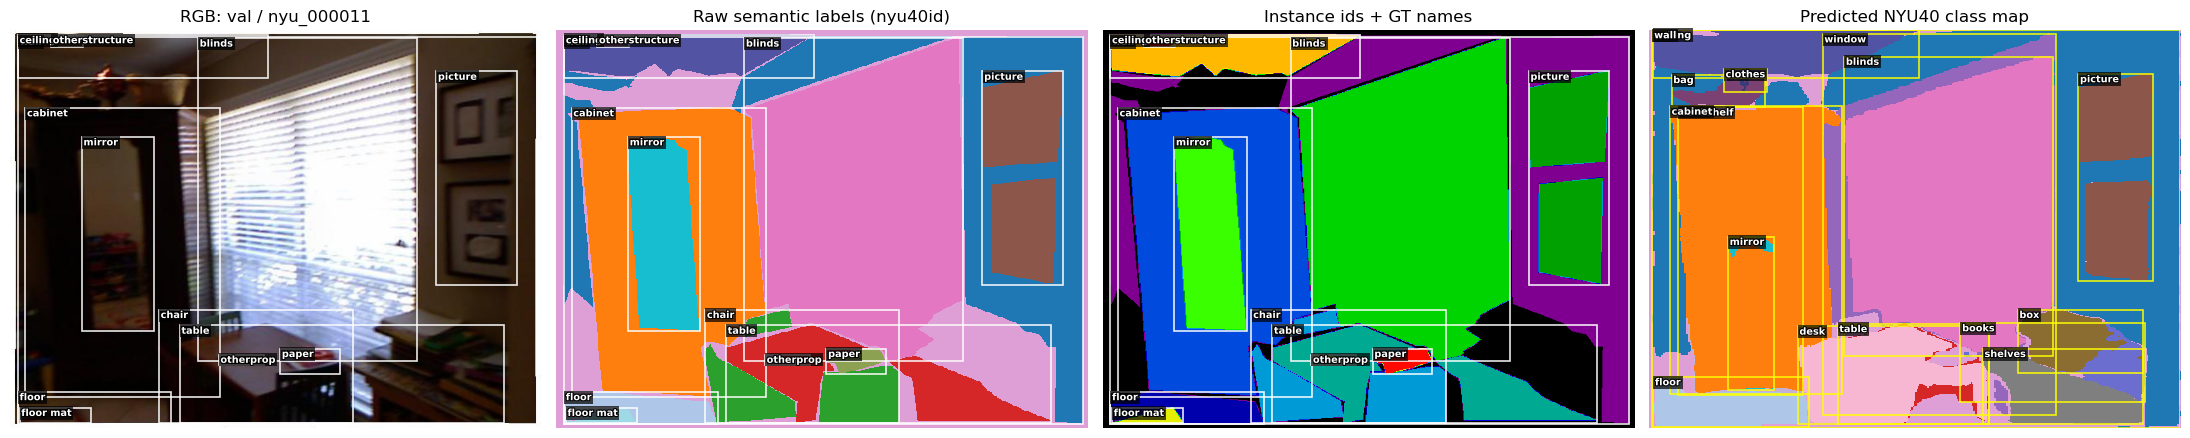

GT instances: 13
Predicted segments: 16
GT object names: ['blinds', 'cabinet', 'ceiling', 'chair', 'floor', 'floor mat', 'mirror', 'otherprop', 'otherstructure', 'paper', 'picture', 'table', 'wall']
Predicted object names: ['bag', 'blinds', 'books', 'bookshelf', 'box', 'cabinet', 'ceiling', 'clothes', 'desk', 'floor', 'mirror', 'picture', 'shelves', 'table', 'wall', 'window']


In [104]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import matplotlib as mpl
from collections import Counter


def class_map_from_instance_output(result: dict[str, Any], ignore_index: int = IGNORE_INDEX) -> np.ndarray:
    segmentation = result["segmentation"]
    if isinstance(segmentation, torch.Tensor):
        segmentation = segmentation.cpu()
    class_map = torch.full_like(segmentation, fill_value=ignore_index)
    for segment in result["segments_info"]:
        class_map[segmentation == segment["id"]] = int(segment["label_id"])
    return class_map.cpu().numpy()


def extract_gt_instance_annotations(instance_map: np.ndarray, semantic_map: np.ndarray) -> list[dict[str, Any]]:
    annotations: list[dict[str, Any]] = []
    for instance_id in sorted(int(x) for x in np.unique(instance_map).tolist()):
        if instance_id == 0:
            continue
        mask = instance_map == instance_id
        if not np.any(mask):
            continue
        nyu40_ids = semantic_map[mask].astype(np.int32)
        nyu40_ids = nyu40_ids[~np.isin(nyu40_ids, list(RAW_IGNORE_IDS))]
        if nyu40_ids.size == 0:
            continue
        majority_nyu40id = int(Counter(nyu40_ids.tolist()).most_common(1)[0][0])
        class_index = normalize_semantic_id(majority_nyu40id)
        if class_index == IGNORE_INDEX:
            continue
        ys, xs = np.where(mask)
        class_name = NYU40_CLASS_NAMES[class_index] if 0 <= class_index < len(NYU40_CLASS_NAMES) else "unknown"
        annotations.append(
            {
                "bbox": (int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())),
                "class_index": int(class_index),
                "class_name": class_name,
            }
        )
    return annotations


def extract_pred_instance_annotations(prediction: dict[str, Any]) -> list[dict[str, Any]]:
    segmentation = prediction["segmentation"]
    if isinstance(segmentation, torch.Tensor):
        segmentation = segmentation.cpu().numpy()
    else:
        segmentation = np.asarray(segmentation)

    annotations: list[dict[str, Any]] = []
    for segment in prediction["segments_info"]:
        segment_id = int(segment["id"])
        class_index = int(segment["label_id"])
        if class_index == IGNORE_INDEX:
            continue
        mask = segmentation == segment_id
        if not np.any(mask):
            continue
        ys, xs = np.where(mask)
        class_name = NYU40_CLASS_NAMES[class_index] if 0 <= class_index < len(NYU40_CLASS_NAMES) else f"class_{class_index}"
        annotations.append(
            {
                "bbox": (int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())),
                "class_index": class_index,
                "class_name": class_name,
            }
        )
    return annotations


def overlay_annotations(ax, annotations: list[dict[str, Any]], box_color: str = "white", max_items: int = 40) -> None:
    for item in annotations[:max_items]:
        x0, y0, x1, y1 = item["bbox"]
        ax.add_patch(
            plt.Rectangle(
                (x0, y0),
                max(1, x1 - x0 + 1),
                max(1, y1 - y0 + 1),
                linewidth=1.2,
                edgecolor=box_color,
                facecolor="none",
                alpha=0.9,
            )
        )
        text = ax.text(
            x0 + 2,
            max(10, y0 + 10),
            item["class_name"],
            fontsize=7,
            color="white",
            weight="bold",
            bbox={"facecolor": "black", "alpha": 0.7, "pad": 1.2, "edgecolor": "none"},
        )
        text.set_path_effects([path_effects.withStroke(linewidth=1.5, foreground="black")])


def build_nyu40_colormap(num_classes: int = 40) -> mpl.colors.ListedColormap:
    # Use 3 qualitative palettes to guarantee enough distinct colors for 40 classes.
    palette_parts = [plt.cm.tab20(np.linspace(0, 1, 20)), plt.cm.tab20b(np.linspace(0, 1, 20)), plt.cm.tab20c(np.linspace(0, 1, 20))]
    colors = np.vstack(palette_parts)[:num_classes]
    return mpl.colors.ListedColormap(colors, name="nyu40_distinct")


model.eval()
sample = val_dataset[11] if len(val_dataset) > 0 else train_dataset[0]
visual_batch = collate_fn([sample])
with torch.no_grad():
    visual_outputs = model(
        pixel_values=visual_batch["pixel_values"].to(device),
        pixel_mask=visual_batch["pixel_mask"].to(device),
    )

prediction = processor.post_process_instance_segmentation(
    visual_outputs,
    target_sizes=[sample["image"].size[::-1]],
)[0]
pred_class_map = class_map_from_instance_output(prediction)

image = np.array(sample["image"])
semantic_map = sample["semantic_map"]
instance_map = sample["instance_map"]

gt_annotations = extract_gt_instance_annotations(instance_map, semantic_map)
pred_annotations = extract_pred_instance_annotations(prediction)

nyu40_cmap = build_nyu40_colormap(num_classes=40)
nyu40_norm = mpl.colors.BoundaryNorm(np.arange(-0.5, 40.5, 1.0), nyu40_cmap.N)

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
axes[0].imshow(image)
axes[0].set_title(f"RGB: {sample['scene_id']} / {sample['frame_id']}")
overlay_annotations(axes[0], gt_annotations, box_color="white")
axes[0].axis("off")

axes[1].imshow(semantic_map, cmap=nyu40_cmap, norm=nyu40_norm, interpolation="nearest")
axes[1].set_title("Raw semantic labels (nyu40id)")
overlay_annotations(axes[1], gt_annotations, box_color="white")
axes[1].axis("off")

axes[2].imshow(instance_map, cmap="nipy_spectral")
axes[2].set_title("Instance ids + GT names")
overlay_annotations(axes[2], gt_annotations, box_color="white")
axes[2].axis("off")

axes[3].imshow(pred_class_map, cmap=nyu40_cmap, norm=nyu40_norm, interpolation="nearest")
axes[3].set_title("Predicted NYU40 class map")
overlay_annotations(axes[3], pred_annotations, box_color="yellow")
axes[3].axis("off")

plt.tight_layout()
plt.show()

gt_names = sorted({item["class_name"] for item in gt_annotations})
pred_names = sorted({item["class_name"] for item in pred_annotations})
print("GT instances:", len(gt_annotations))
print("Predicted segments:", len(pred_annotations))
print("GT object names:", gt_names)
print("Predicted object names:", pred_names)


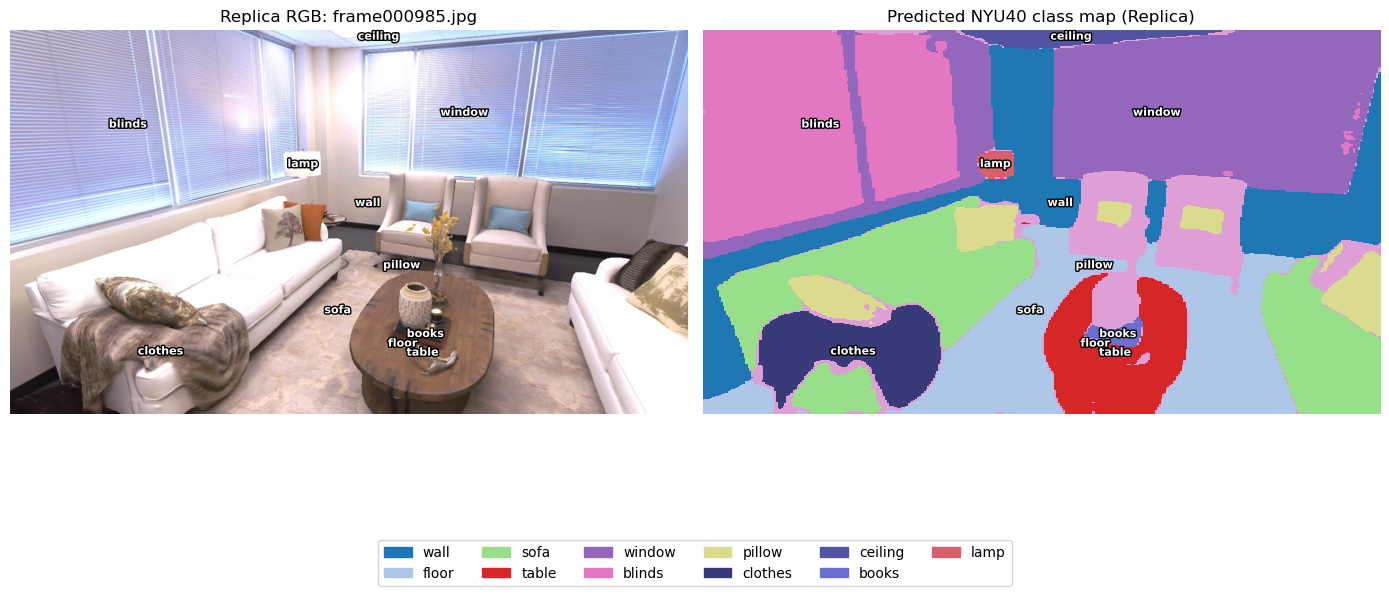

Replica image: /home/abdou/Projects/Python/RTSGS/Datasets/Replica/ThirdParty/Replica/room0/results/frame000985.jpg
Predicted segments: 11
Predicted object names: ['blinds', 'books', 'ceiling', 'clothes', 'floor', 'lamp', 'pillow', 'sofa', 'table', 'wall', 'window']
Top segments: [{'id': 0, 'label_id': 21, 'was_fused': False, 'score': 0.611435}, {'id': 1, 'label_id': 1, 'was_fused': False, 'score': 0.825844}, {'id': 2, 'label_id': 5, 'was_fused': False, 'score': 0.950118}, {'id': 3, 'label_id': 0, 'was_fused': False, 'score': 0.967941}, {'id': 4, 'label_id': 34, 'was_fused': False, 'score': 0.969035}, {'id': 5, 'label_id': 22, 'was_fused': False, 'score': 0.850739}, {'id': 6, 'label_id': 6, 'was_fused': False, 'score': 0.937987}, {'id': 7, 'label_id': 20, 'was_fused': False, 'score': 0.673965}, {'id': 8, 'label_id': 8, 'was_fused': False, 'score': 0.752289}, {'id': 9, 'label_id': 12, 'was_fused': False, 'score': 0.862006}]


In [106]:
from pathlib import Path
import matplotlib.patches as mpatches

# Forward pass on a specific Replica frame.
replica_image_path = Path("/home/abdou/Projects/Python/RTSGS/Datasets/Replica/ThirdParty/Replica/room0/results/frame000985.jpg")
if not replica_image_path.exists():
    raise FileNotFoundError(f"Replica frame not found: {replica_image_path}")

replica_image_pil = Image.open(replica_image_path).convert("RGB")
replica_image_np = np.array(replica_image_pil)

replica_encoded = processor(images=[replica_image_pil], return_tensors="pt")
with torch.no_grad():
    replica_outputs = model(
        pixel_values=replica_encoded["pixel_values"].to(device),
        pixel_mask=replica_encoded["pixel_mask"].to(device),
    )

replica_prediction = processor.post_process_instance_segmentation(
    replica_outputs,
    target_sizes=[replica_image_pil.size[::-1]],
)[0]
replica_pred_class_map = class_map_from_instance_output(replica_prediction)

if "nyu40_cmap" not in globals() or "nyu40_norm" not in globals():
    nyu40_cmap = build_nyu40_colormap(num_classes=40)
    nyu40_norm = mpl.colors.BoundaryNorm(np.arange(-0.5, 40.5, 1.0), nyu40_cmap.N)


def extract_label_positions(prediction: dict[str, Any]) -> list[dict[str, Any]]:
    segmentation = prediction["segmentation"]
    if isinstance(segmentation, torch.Tensor):
        segmentation = segmentation.cpu().numpy()
    else:
        segmentation = np.asarray(segmentation)

    labels: list[dict[str, Any]] = []
    for segment in prediction["segments_info"]:
        seg_id = int(segment["id"])
        class_index = int(segment["label_id"])
        if class_index == IGNORE_INDEX:
            continue
        mask = segmentation == seg_id
        if not np.any(mask):
            continue
        ys, xs = np.where(mask)
        cx = int(xs.mean())
        cy = int(ys.mean())
        class_name = NYU40_CLASS_NAMES[class_index] if 0 <= class_index < len(NYU40_CLASS_NAMES) else f"class_{class_index}"
        labels.append(
            {
                "class_index": class_index,
                "class_name": class_name,
                "x": cx,
                "y": cy,
            }
        )
    return labels


replica_labels = extract_label_positions(replica_prediction)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(replica_image_np)
axes[0].set_title(f"Replica RGB: {replica_image_path.name}")
axes[0].axis("off")

axes[1].imshow(replica_pred_class_map, cmap=nyu40_cmap, norm=nyu40_norm, interpolation="nearest")
axes[1].set_title("Predicted NYU40 class map (Replica)")
axes[1].axis("off")

for item in replica_labels:
    text_kwargs = {
        "ha": "center",
        "va": "center",
        "fontsize": 8,
        "fontweight": "bold",
        "color": "white",
        "path_effects": [path_effects.withStroke(linewidth=2, foreground="black")],
    }
    axes[0].text(item["x"], item["y"], item["class_name"], **text_kwargs)
    axes[1].text(item["x"], item["y"], item["class_name"], **text_kwargs)

unique_classes = sorted({(item["class_index"], item["class_name"]) for item in replica_labels}, key=lambda x: x[0])
legend_handles = []
for class_index, class_name in unique_classes:
    color = nyu40_cmap(nyu40_norm(class_index))
    legend_handles.append(mpatches.Patch(color=color, label=class_name))

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=min(6, max(1, len(legend_handles))),
    frameon=True,
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

replica_pred_names = sorted({item["class_name"] for item in replica_labels})
print("Replica image:", str(replica_image_path))
print("Predicted segments:", len(replica_labels))
print("Predicted object names:", replica_pred_names)
print("Top segments:", replica_prediction["segments_info"][:10])

## Teacher -> Student Distillation For Constrained Instance Splitting

This section freezes the current `model` as the teacher and trains a lightweight student splitter.

Design constraints implemented:
- Student is **allowed to split** teacher regions into multiple instances.
- Student is **not allowed** to change semantic classes.
- Student is **not allowed** to create masks outside teacher semantic support.

Concretely, final instance maps are always built by partitioning teacher class regions only.

In [107]:
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
from scipy import ndimage as ndi


# ---------- Teacher (frozen) ----------
teacher_model = model
teacher_model.eval()
for parameter in teacher_model.parameters():
    parameter.requires_grad = False


# ---------- Student: SAME architecture as teacher ----------
student_model = Mask2FormerForUniversalSegmentation.from_pretrained(
    BASE_MODEL_ID,
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
).to(device)

# Warm-start student from current teacher weights.
student_model.load_state_dict(teacher_model.state_dict(), strict=False)
student_model.train()

optimizer = torch.optim.AdamW(student_model.parameters(), lr=5e-5, weight_decay=1e-4)


# ---------- Distillation config ----------
DISTILL_MAX_SAMPLES = 64
DISTILL_BATCH_SIZE = 2
DISTILL_EPOCHS = 1
DISTILL_TEMPERATURE = 2.0
DISTILL_ALPHA_CLASS = 1.0
DISTILL_ALPHA_MASK = 1.0


def distill_collate_fn(batch: list[dict[str, Any]]) -> dict[str, Any]:
    images = [item["image"] for item in batch]
    encoded = processor(images=images, return_tensors="pt")
    encoded["target_sizes"] = [image.size[::-1] for image in images]
    encoded["images_pil"] = images
    return encoded


subset_count = min(DISTILL_MAX_SAMPLES, len(train_dataset))
distill_subset = Subset(train_dataset, list(range(subset_count)))
distill_loader = DataLoader(
    distill_subset,
    batch_size=DISTILL_BATCH_SIZE,
    shuffle=True,
    collate_fn=distill_collate_fn,
)

print("Distillation subset size:", subset_count)
print("Distillation epochs:", DISTILL_EPOCHS)
print("Student architecture:", student_model.__class__.__name__)


for epoch in range(1, DISTILL_EPOCHS + 1):
    student_model.train()
    running_total = 0.0
    running_class = 0.0
    running_mask = 0.0
    running_steps = 0

    for batch in distill_loader:
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)

        with torch.no_grad():
            teacher_outputs = teacher_model(pixel_values=pixel_values, pixel_mask=pixel_mask)

        student_outputs = student_model(pixel_values=pixel_values, pixel_mask=pixel_mask)

        teacher_class_logits = teacher_outputs.class_queries_logits.detach()
        student_class_logits = student_outputs.class_queries_logits

        teacher_mask_logits = teacher_outputs.masks_queries_logits.detach()
        student_mask_logits = student_outputs.masks_queries_logits

        temperature = DISTILL_TEMPERATURE
        class_loss = F.kl_div(
            F.log_softmax(student_class_logits / temperature, dim=-1),
            F.softmax(teacher_class_logits / temperature, dim=-1),
            reduction="batchmean",
        ) * (temperature * temperature)

        mask_loss = F.binary_cross_entropy_with_logits(
            student_mask_logits,
            torch.sigmoid(teacher_mask_logits),
        )

        total_loss = DISTILL_ALPHA_CLASS * class_loss + DISTILL_ALPHA_MASK * mask_loss

        optimizer.zero_grad(set_to_none=True)
        total_loss.backward()
        optimizer.step()

        running_total += float(total_loss.detach().cpu())
        running_class += float(class_loss.detach().cpu())
        running_mask += float(mask_loss.detach().cpu())
        running_steps += 1

    denom = max(1, running_steps)
    print(
        f"[distill] epoch={epoch} total={running_total / denom:.4f} "
        f"class={running_class / denom:.4f} mask={running_mask / denom:.4f}"
    )


# ---------- Constrained decoding ----------
def teacher_class_map_from_image(image_pil: Image.Image) -> np.ndarray:
    encoded = processor(images=[image_pil], return_tensors="pt")
    with torch.no_grad():
        outputs = teacher_model(
            pixel_values=encoded["pixel_values"].to(device),
            pixel_mask=encoded["pixel_mask"].to(device),
        )
    prediction = processor.post_process_instance_segmentation(outputs, target_sizes=[image_pil.size[::-1]])[0]
    class_map = class_map_from_instance_output(prediction, ignore_index=IGNORE_INDEX)
    return class_map.astype(np.int32)


def constrained_instances_from_teacher_and_student(
    teacher_class_map: np.ndarray,
    student_prediction: dict[str, Any],
    min_area: int = 9,
) -> tuple[np.ndarray, list[dict[str, Any]]]:
    """
    Hard constraints:
      1) final class per pixel must come from teacher class map
      2) final mask support must be subset of teacher support (!= IGNORE)
    Student can only split teacher regions into multiple instances.
    """
    segmentation = student_prediction["segmentation"]
    if isinstance(segmentation, torch.Tensor):
        segmentation = segmentation.cpu().numpy()
    else:
        segmentation = np.asarray(segmentation)

    valid_support = teacher_class_map != IGNORE_INDEX
    h, w = teacher_class_map.shape
    instance_map = np.zeros((h, w), dtype=np.int32)
    annotations: list[dict[str, Any]] = []
    next_instance_id = 1

    for segment in student_prediction["segments_info"]:
        seg_id = int(segment["id"])
        seg_mask = (segmentation == seg_id) & valid_support
        if not np.any(seg_mask):
            continue

        teacher_labels = teacher_class_map[seg_mask]
        if teacher_labels.size == 0:
            continue

        majority_class = int(Counter(teacher_labels.tolist()).most_common(1)[0][0])
        if majority_class == IGNORE_INDEX:
            continue

        # Enforce semantic consistency: segment cannot cross teacher class boundaries.
        constrained_mask = seg_mask & (teacher_class_map == majority_class)
        if not np.any(constrained_mask):
            continue

        # Allow extra splitting when disconnected regions exist.
        comp_map, comp_count = ndi.label(constrained_mask.astype(np.uint8))
        for comp_id in range(1, comp_count + 1):
            comp = comp_map == comp_id
            if comp.sum() < min_area:
                continue

            instance_map[comp] = next_instance_id
            ys, xs = np.where(comp)
            class_name = NYU40_CLASS_NAMES[majority_class] if 0 <= majority_class < len(NYU40_CLASS_NAMES) else f"class_{majority_class}"
            annotations.append(
                {
                    "instance_id": next_instance_id,
                    "class_index": majority_class,
                    "class_name": class_name,
                    "bbox": (int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())),
                }
            )
            next_instance_id += 1

    return instance_map, annotations


# ---------- Constrained inference demo ----------
student_model.eval()
replica_teacher_class_map = teacher_class_map_from_image(replica_image_pil)

replica_encoded = processor(images=[replica_image_pil], return_tensors="pt")
with torch.no_grad():
    student_outputs = student_model(
        pixel_values=replica_encoded["pixel_values"].to(device),
        pixel_mask=replica_encoded["pixel_mask"].to(device),
    )

student_prediction = processor.post_process_instance_segmentation(
    student_outputs,
    target_sizes=[replica_image_pil.size[::-1]],
)[0]

replica_instance_map, replica_instance_annotations = constrained_instances_from_teacher_and_student(
    teacher_class_map=replica_teacher_class_map,
    student_prediction=student_prediction,
)

if "nyu40_cmap" not in globals() or "nyu40_norm" not in globals():
    nyu40_cmap = build_nyu40_colormap(num_classes=40)
    nyu40_norm = mpl.colors.BoundaryNorm(np.arange(-0.5, 40.5, 1.0), nyu40_cmap.N)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(replica_image_np)
axes[0].set_title("Replica RGB")
axes[0].axis("off")

axes[1].imshow(replica_teacher_class_map, cmap=nyu40_cmap, norm=nyu40_norm, interpolation="nearest")
axes[1].set_title("Teacher class map (fixed)")
axes[1].axis("off")

axes[2].imshow(replica_instance_map, cmap="nipy_spectral")
axes[2].set_title("Student instances (constrained)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("Constrained instances:", len(replica_instance_annotations))
print("First 10 instances:", replica_instance_annotations[:10])

Some weights of Mask2FormerForUniversalSegmentation were not initialized from the model checkpoint at facebook/mask2former-swin-base-ade-semantic and are newly initialized because the shapes did not match:
- class_predictor.bias: found shape torch.Size([151]) in the checkpoint and torch.Size([41]) in the model instantiated
- class_predictor.weight: found shape torch.Size([151, 256]) in the checkpoint and torch.Size([41, 256]) in the model instantiated
- criterion.empty_weight: found shape torch.Size([151]) in the checkpoint and torch.Size([41]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Distillation subset size: 64
Distillation epochs: 1
Student architecture: Mask2FormerForUniversalSegmentation


OutOfMemoryError: CUDA out of memory. Tried to allocate 32.00 MiB. GPU 0 has a total capacty of 5.61 GiB of which 67.00 MiB is free. Including non-PyTorch memory, this process has 5.27 GiB memory in use. Of the allocated memory 4.98 GiB is allocated by PyTorch, and 183.56 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF